In [60]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian
from copy import copy
from koala.lattice import INVALID
from koala import example_graphs as eg
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)
from tqdm import tqdm

import matplotlib as mpl
from collections import Counter

from dimer_models.kasteleyn import find_kasteleyn_number, find_local_dimer_probability

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import pickle

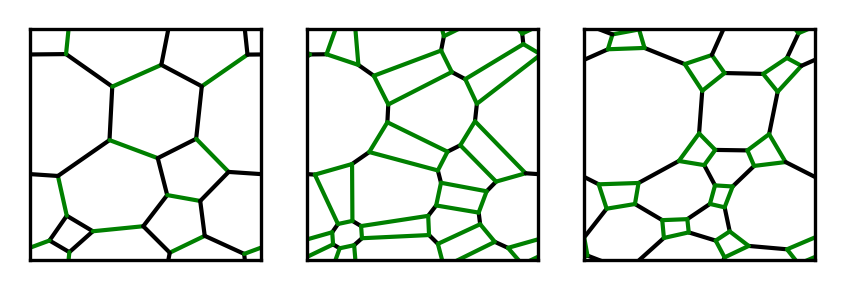

In [61]:
from dimer_models.lattice_generation import expand_edges_to_squares
import pickle

n = 10

# lattice = generate_lattice(uniform(n))
# lattice = gu.com_relaxation(lattice)

with open("lattice_1.pkl", "rb") as f:
    # pickle.dump(lattice, f)
    lattice = pickle.load(f)


dim1 = gu.dimerise(lattice)

out = expand_edges_to_squares(lattice, np.where(dim1)[0])

nn = 2 * lattice.n_edges // 3
out_colours = np.array([0] * nn + [1] * (out.n_edges - nn))
out_rel = gu.com_relaxation(out)
fig, ax = plt.subplots(1, 3, figsize=(3.375, 3.375 / 3), dpi=300)


ax = ax.flatten()
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

pl.plot_edges(
    lattice, labels=dim1, ax=ax[0], color_scheme=["black", "green"], linewidth=1
)
pl.plot_edges(
    out, ax=ax[1], linewidth=1, color_scheme=["black", "green"], labels=out_colours
)
pl.plot_edges(
    out_rel, ax=ax[2], linewidth=1, color_scheme=["black", "green"], labels=out_colours
)

bipart = gu.distance_matrix(out_rel)[2] % 2
assert np.all(np.sum(bipart[out_rel.edges.indices], axis=1) == 1)

plt.savefig("voronoi_a.pdf")

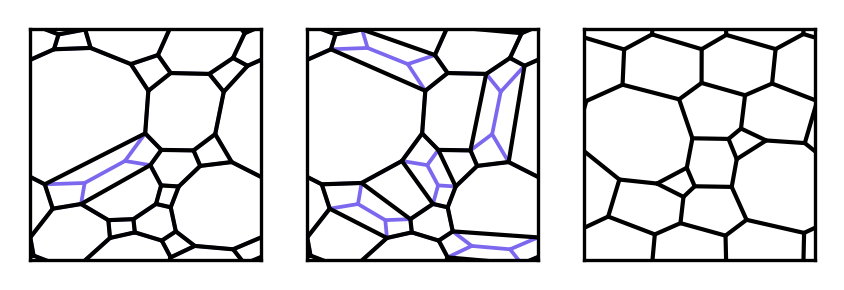

In [62]:
from dimer_models.lattice_generation import expand_edges

s = 1
fig, ax = plt.subplots(1, 3, figsize=(3.375 * s, 3.375 * s / 3), dpi=300)
ax = ax.flatten()
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

chosen_edge = 5

# pl.plot_edges(out_rel, color_scheme=["black", "green"], linewidth=1, ax=ax[0])
# pl.plot_edge_indices(out_rel, ax = ax[0],)

lat_2 = expand_edges(out_rel, [4])
pl.plot_edges(lat_2, color_scheme=["black", "green"], linewidth=1, ax=ax[0])
pl.plot_edges(
    out_rel, color_scheme=["mediumslateblue"], linewidth=0.9, ax=ax[0], zorder=0
)

lat_3 = expand_edges(out_rel, [5, 3, 15, 8, 11])
# lat_3 = gu.com_relaxation(lat_3)
pl.plot_edges(lat_3, color_scheme=["black", "green"], linewidth=1, ax=ax[1])
pl.plot_edges(
    out_rel, color_scheme=["mediumslateblue"], linewidth=0.9, ax=ax[1], zorder=0
)


pl.plot_edges(
    gu.com_relaxation(lat_3), color_scheme=["black", "green"], linewidth=1, ax=ax[2]
)
plt.savefig("voronoi_b.pdf")

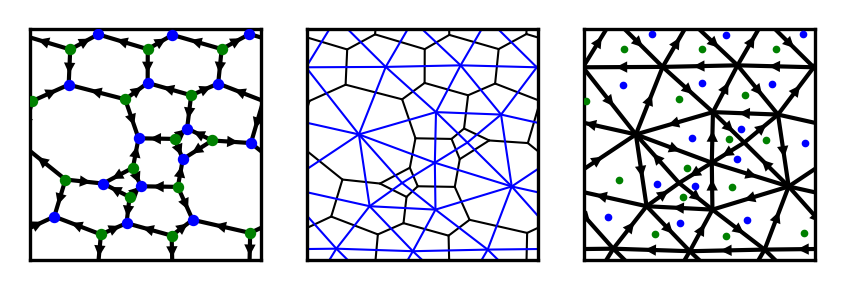

In [63]:
bipartition = gu.distance_matrix(lat_3)[2] % 2
l = gu.com_relaxation(lat_3)

directions = bipartition[l.edges.indices]
directions = directions[:, 0] - directions[:, 1]

dual = gu.make_dual(l, reg_steps=0, use_point_averages=False)

fig, ax = plt.subplots(1, 3, figsize=(3.375, 3.375 / 3), dpi=300)
ax = ax.flatten()
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

pl.plot_edges(
    l,
    color_scheme=["black", "green"],
    linewidth=1,
    ax=ax[0],
    directions=directions,
    arrow_head_length=0.02,
)
ax[0].scatter(*l.vertices.positions[bipartition == 0].T, s=3, zorder=10, c="b")
ax[0].scatter(*l.vertices.positions[bipartition == 1].T, s=3, zorder=10, c="g")

pl.plot_edges(
    l,
    color_scheme=["black", "green"],
    linewidth=0.5,
    ax=ax[1],
    arrow_head_length=0.02,
)
pl.plot_edges(
    dual,
    color_scheme=["blue", "green"],
    linewidth=0.5,
    ax=ax[1],
    arrow_head_length=0.02,
)


pl.plot_edges(
    dual,
    color_scheme=["black", "green"],
    linewidth=1,
    ax=ax[2],
    directions=directions,
    arrow_head_length=0.02,
)
ax[2].scatter(*l.vertices.positions[bipartition == 0].T, s=0.7, zorder=10, c="b")
ax[2].scatter(*l.vertices.positions[bipartition == 1].T, s=0.7, zorder=10, c="g")

# plt.savefig("height_a.pdf")

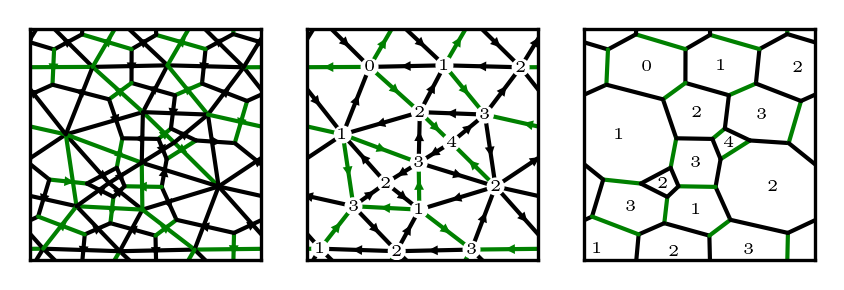

In [102]:
from dimer_models.dimerisation import dimer_height

l_shifted = Lattice(
    l.vertices.positions + np.array([-0.07, 0.00]), l.edges.indices, l.edges.crossing
)

dual_shifted = Lattice(
    dual.vertices.positions + np.array([-0.07, 0.00]),
    dual.edges.indices,
    dual.edges.crossing,
)

fig, ax = plt.subplots(1, 3, figsize=(3.375, 3.375 / 3), dpi=300)
ax = ax.flatten()
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")


dimerisation_1 = gu.dimerise(l_shifted, 1000)[160]
heights = dimer_height(l_shifted, dimerisation_1, bipart=bipartition)


pl.plot_edges(
    l_shifted,
    labels=dimerisation_1,
    ax=ax[0],
    color_scheme=["black", "green"],
    linewidth=1,
    directions=directions,
)
pl.plot_edges(
    dual_shifted,
    labels=dimerisation_1,
    ax=ax[1],
    color_scheme=["black", "green"],
    linewidth=1,
    directions=directions,
)
pl.plot_edges(
    dual_shifted,
    labels=dimerisation_1,
    ax=ax[0],
    color_scheme=["black", "green"],
    linewidth=1,
    zorder=-10,
)
pl.plot_edges(
    l_shifted,
    labels=dimerisation_1,
    ax=ax[2],
    color_scheme=["black", "green"],
    linewidth=1,
)


# plot height labels
for i, txt in enumerate(heights):

    pos = l_shifted.plaquettes[i].center
    # ax[0].annotate(
    #     str(txt),
    #     pos % 1,
    #     textcoords="offset points",
    #     xytext=(1.6, -0.9),
    #     ha="right",
    #     fontsize=4,
    #     zorder=10,
    # )
    ax[1].annotate(
        str(txt),
        pos % 1,
        textcoords="offset points",
        xytext=(1.6, -0.9),
        ha="right",
        fontsize=4,
        zorder=10,
    )
    ax[2].annotate(
        str(txt),
        pos % 1,
        textcoords="offset points",
        xytext=(1.6, -0.9),
        ha="right",
        fontsize=4,
        zorder=10,
    )

    # circle behind text
    circle = plt.Circle(
        pos % 1,
        0.03,
        color="white",
        zorder=9,
        alpha=1,
    )
    ax[1].add_artist(circle)

plt.savefig("height_b.pdf")

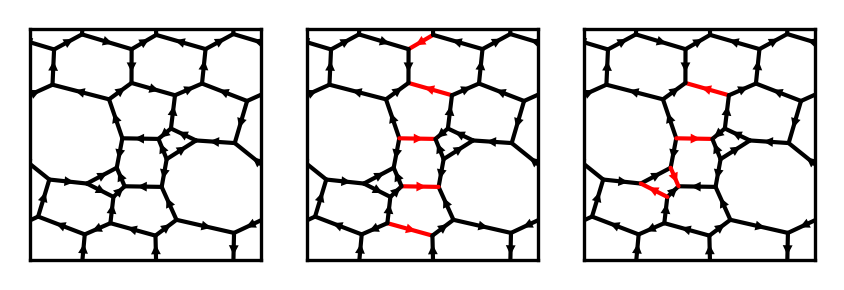

In [ ]:
# show kasteleyn matrix
kasteleyn_orientation = ujk_from_fluxes(
    l_shifted, np.array([-1] * l_shifted.n_plaquettes)
)

sector_by_edge = np.sign(l_shifted.vertices.positions[l_shifted.edges.indices] - 0.5)
cross_middle = np.sum(sector_by_edge, axis=1) == 0

x_flip_edges = cross_middle[:, 0] * (l_shifted.edges.crossing[:, 0] == 0)
y_flip_edges = cross_middle[:, 1] * (l_shifted.edges.crossing[:, 1] == 0)

kasteleyn_orientation[y_flip_edges] *= -1

new_kasteleyn_orientation = copy(kasteleyn_orientation)
new_kasteleyn_orientation[x_flip_edges] *= -1


fig, ax = plt.subplots(1, 3, figsize=(3.375, 3.375 / 3), dpi=300)
ax = ax.flatten()
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

pl.plot_edges(
    l_shifted,
    ax=ax[0],
    color_scheme=["black", "green"],
    linewidth=1,
    directions=kasteleyn_orientation,
)

pl.plot_edges(
    l_shifted,
    ax=ax[1],
    color_scheme=["black", "red", "blue"],
    linewidth=1,
    directions=new_kasteleyn_orientation,
    labels=x_flip_edges,
)

plaq_choice = np.array([-1] * l_shifted.n_plaquettes)
plaq_choice[8] = 1
plaq_choice[13] = 1

plaq_kasteleyn_orientation = ujk_from_fluxes(
    l_shifted, plaq_choice, kasteleyn_orientation
)
diffs = (plaq_kasteleyn_orientation * kasteleyn_orientation) == -1

pl.plot_edges(
    l_shifted,
    ax=ax[2],
    color_scheme=["black", "red"],
    linewidth=1,
    directions=plaq_kasteleyn_orientation,
    labels=diffs,
)
# pl.plot_plaquette_indices(l_shifted, ax=ax[2], fontsize=3)

plt.savefig("kasteleyn.pdf")